In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   # 0.13.2
import xgboost as xgb

# train test split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
%matplotlib inline
sns .set_style('whitegrid')

XGBoost ek tree-based model hai ✅
👉 Isme scaling (StandardScaler/MinMaxScaler) ki zarurat nahi hoti.

 Outliers check karne hain
✅ Skewness check karni hai
✅ Categorical encode karna hai

In [2]:
df = pd.read_csv("Wholesale-customers-data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [4]:
df.skew()

,0
Channel,0.760951
Region,-1.283627
Fresh,2.561323
Milk,4.053755
Grocery,3.587429
Frozen,5.907986
Detergents_Paper,3.631851
Delicassen,11.151586


In [5]:
x = df.drop ('Channel', axis = 1)
y = df ['Channel'].map({1:1, 2:0}) # yaha pe channel 1 ko 1 aur channel 2 ko 0 map kar diya hai
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42)

In [6]:
params = {
    'objective':'binary:logistic', # (Model ka Goal kya hai?)
    'max_depth':4, # (Decision Tree kitna bada hoga?)
    'learning_rate':0.1, # (Seekhne ki speed)
    'n_estimators':100, # (Kitne trees banane hain?)
    'alpha':10 # (L1 regularization, overfitting ko rokne ke liye)
}

model = XGBClassifier(**params)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

Symbol	Use
    \n *	List/tuple unpack karta hai
   \n **	Dictionary unpack karta hai
    example
   <!-- # def greet(name, age):
    print(name, age)

data = {'name': 'Rahul', 'age': 25}

greet(**data) -->

In [7]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.8977272727272727

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.91      0.82        23
           1       0.97      0.89      0.93        65

    accuracy                           0.90        88
   macro avg       0.86      0.90      0.88        88
weighted avg       0.91      0.90      0.90        88



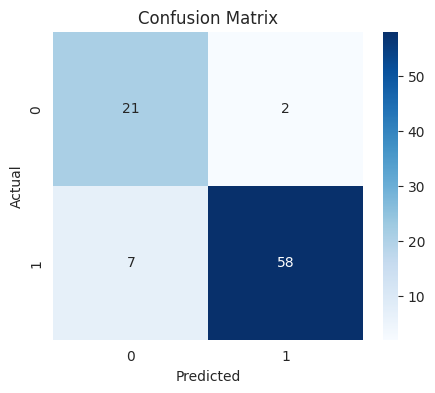

In [8]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<Figure size 800x600 with 0 Axes>

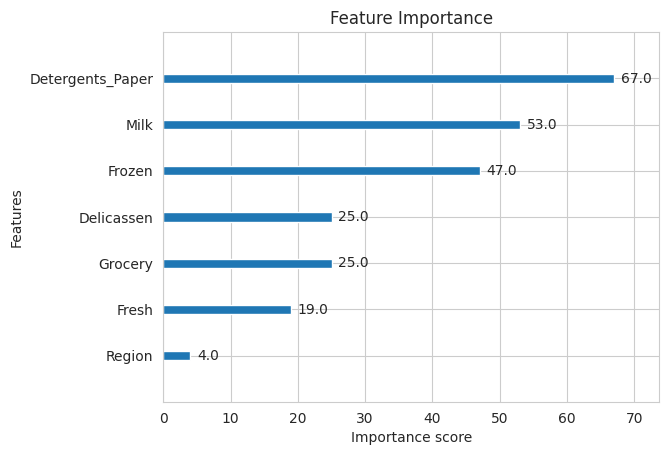

In [9]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 2000x1000 with 0 Axes>

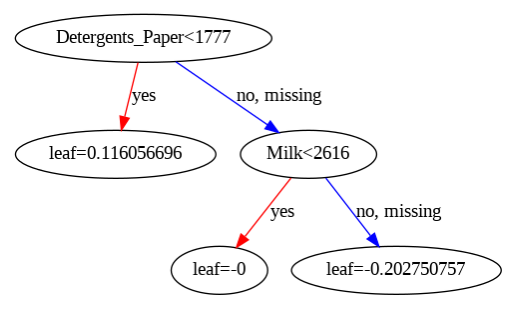

In [10]:
import graphviz
plt.figure(figsize=(20,10))
xgb.plot_tree(model, num_trees=0)
plt.show()